# Nectar Data Scientist Challenge

**Intelligent Facilities Platform — IoT telemetry analysis, predictive maintenance,
energy forecasting, anomaly detection and asset connectivity analysis.**

This notebook is organised task-by-task, matching the challenge brief:

1. Data generation (synthetic telemetry, since no real dataset was provided)
2. Exploratory Data Analysis
3. Predictive Maintenance (24h failure prediction)
4. Energy Consumption Forecasting
5. Anomaly Detection
6. Multi-Asset Connectivity Analysis

Assumptions are noted inline where a choice had to be made.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RNG_SEED = 42
np.random.seed(RNG_SEED)


## 0. Synthetic Data Generation

No real dataset came with the challenge, so I generated one that follows the exact
schema given in the brief (sensor telemetry, asset metadata, asset connectivity).

Assumptions I made:
- 3 sites, each with 1-2 buildings, ~10-20 assets per building (Chillers, AHUs, Pumps,
  Energy Meters, Env Sensors), which matches the example hierarchy in the brief.
- 60 days of hourly readings per asset.
- Assets have a slow "degradation" trend (rising vibration/temperature/power) that
  eventually crosses a threshold and produces a fault — so `fault_flag` is not random
  noise, it is actually predictable from the sensor trend, which is what makes Task 2
  possible in the first place.
- A handful of anomalies (spikes, drift, stuck sensors) are injected on top for Task 4.
- The connectivity table intentionally has a few duplicate edges and one orphan asset,
  to make the data-quality part of Task 5 meaningful.

In [2]:
SITES = ["SITE_A", "SITE_B", "SITE_C"]
BUILDINGS = {"SITE_A": ["BLD_A1", "BLD_A2"], "SITE_B": ["BLD_B1"], "SITE_C": ["BLD_C1", "BLD_C2"]}
ASSET_TYPES = ["Chiller", "AHU", "Pump", "EnergyMeter", "EnvSensor"]
MANUFACTURERS = ["Carrier", "Trane", "Johnson Controls", "Daikin", "Siemens"]

rng = np.random.default_rng(RNG_SEED)
assets = {}
counter = 1

def next_id():
    global counter
    aid = f"AST_{counter:04d}"
    counter += 1
    return aid

for site in SITES:
    for bld in BUILDINGS[site]:
        for _ in range(rng.integers(1, 3)):
            chiller = next_id()
            assets[chiller] = dict(asset_id=chiller, site_id=site, building_id=bld,
                asset_name=f"Chiller-{chiller[-2:]}", asset_type="Chiller",
                manufacturer=rng.choice(MANUFACTURERS),
                installation_date=pd.Timestamp("2018-01-01") + pd.Timedelta(days=int(rng.integers(0, 2200))),
                capacity=round(rng.uniform(200, 800), 1), parent_asset_id=None,
                degrade_rate=rng.uniform(0.0008, 0.0025))
            for _ in range(rng.integers(2, 5)):
                ahu = next_id()
                assets[ahu] = dict(asset_id=ahu, site_id=site, building_id=bld,
                    asset_name=f"AHU-{ahu[-2:]}", asset_type="AHU",
                    manufacturer=rng.choice(MANUFACTURERS),
                    installation_date=pd.Timestamp("2018-01-01") + pd.Timedelta(days=int(rng.integers(0, 2200))),
                    capacity=round(rng.uniform(5, 40), 1), parent_asset_id=chiller,
                    degrade_rate=rng.uniform(0.0005, 0.0020))
        for _ in range(rng.integers(1, 3)):
            pump = next_id()
            assets[pump] = dict(asset_id=pump, site_id=site, building_id=bld,
                asset_name=f"Pump-{pump[-2:]}", asset_type="Pump",
                manufacturer=rng.choice(MANUFACTURERS),
                installation_date=pd.Timestamp("2018-01-01") + pd.Timedelta(days=int(rng.integers(0, 2200))),
                capacity=round(rng.uniform(10, 100), 1), parent_asset_id=None,
                degrade_rate=rng.uniform(0.0006, 0.0022))
            meter = next_id()
            assets[meter] = dict(asset_id=meter, site_id=site, building_id=bld,
                asset_name=f"EnergyMeter-{meter[-2:]}", asset_type="EnergyMeter",
                manufacturer=rng.choice(MANUFACTURERS),
                installation_date=pd.Timestamp("2019-01-01") + pd.Timedelta(days=int(rng.integers(0, 1800))),
                capacity=np.nan, parent_asset_id=pump,
                degrade_rate=rng.uniform(0.0001, 0.0006))
        for _ in range(2):
            sensor = next_id()
            assets[sensor] = dict(asset_id=sensor, site_id=site, building_id=bld,
                asset_name=f"EnvSensor-{sensor[-2:]}", asset_type="EnvSensor",
                manufacturer=rng.choice(MANUFACTURERS),
                installation_date=pd.Timestamp("2019-01-01") + pd.Timedelta(days=int(rng.integers(0, 1800))),
                capacity=np.nan, parent_asset_id=None,
                degrade_rate=rng.uniform(0.0001, 0.0004))

asset_metadata = pd.DataFrame(assets.values())
# one asset deliberately made an orphan for the data-quality check later
asset_metadata.loc[asset_metadata.sample(1, random_state=1).index, "parent_asset_id"] = "AST_9999"
print(f"Generated {len(asset_metadata)} assets across {len(SITES)} sites")
asset_metadata.head()


Generated 51 assets across 3 sites


,asset_id,site_id,building_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id,degrade_rate
0,AST_0001,SITE_A,BLD_A1,Chiller-01,Chiller,Daikin,2021-12-11,715.2,NaN,0.001986
1,AST_0002,SITE_A,BLD_A1,AHU-02,AHU,Trane,2018-07-27,39.1,AST_0001,0.001642
2,AST_0003,SITE_A,BLD_A1,AHU-03,AHU,Daikin,2022-09-26,9.5,AST_0001,0.001176
3,AST_0004,SITE_A,BLD_A1,AHU-04,AHU,Johnson Controls,2020-03-26,37.4,AST_0001,0.001466
4,AST_0005,SITE_A,BLD_A1,Pump-05,Pump,Siemens,2021-04-14,30.5,NaN,0.001487


In [3]:
# --- asset connectivity table ---
edges = []
for aid, info in assets.items():
    if info["parent_asset_id"] and info["parent_asset_id"] != "AST_9999":
        conn_type = "Supplies" if info["asset_type"] in ("AHU", "EnergyMeter") else "Controls"
        edges.append((info["parent_asset_id"], aid, conn_type, round(rng.uniform(0.5, 1.0), 2)))

asset_connectivity = pd.DataFrame(edges, columns=["source_asset_id", "target_asset_id",
                                                    "connection_type", "relationship_strength"])
# inject a couple of duplicate edges on purpose (data quality issue for Task 5)
asset_connectivity = pd.concat([asset_connectivity, asset_connectivity.sample(3, random_state=2)],
                                ignore_index=True)
print(f"Generated {len(asset_connectivity)} connections ({asset_connectivity.duplicated().sum()} duplicates)")
asset_connectivity.head()


Generated 30 connections (3 duplicates)


,source_asset_id,target_asset_id,connection_type,relationship_strength
0,AST_0001,AST_0002,Supplies,0.63
1,AST_0001,AST_0003,Supplies,0.67
2,AST_0001,AST_0004,Supplies,0.76
3,AST_0005,AST_0006,Supplies,0.72
4,AST_0009,AST_0010,Supplies,0.51


In [4]:
# --- hourly telemetry, 60 days per asset ---
HOURS = pd.date_range("2025-01-01", periods=60 * 24, freq="h")
rows = []

for aid, info in assets.items():
    # wear builds up gradually across the 60-day observation window itself (not from
    # the asset's original install date, which for older assets would already be
    # fully worn before the window even starts) - each asset gets its own pace, so
    # some fail early, some fail late, and some don't fail in this window at all.
    hours_elapsed = np.arange(len(HOURS))
    wear = 1 - np.exp(-info["degrade_rate"] * hours_elapsed)  # 0 -> ~1 over the window

    hour_of_day = HOURS.hour.values
    day_of_week = HOURS.dayofweek.values
    is_business_hours = ((hour_of_day >= 8) & (hour_of_day <= 19) & (day_of_week < 5)).astype(float)

    diurnal = np.sin((hour_of_day - 6) / 24 * 2 * np.pi)
    occupancy = np.clip((is_business_hours * rng.integers(10, 60) *
                          (1 + 0.15 * rng.normal(size=len(HOURS)))).round(), 0, None)

    base_temp = 22 + 3 * diurnal + rng.normal(0, 0.4, len(HOURS)) + wear * 4
    humidity = 45 + 8 * diurnal + rng.normal(0, 2, len(HOURS))
    pressure = 101.3 + rng.normal(0, 0.3, len(HOURS)) - wear * 0.5
    vibration = 0.3 + wear * 2.5 + rng.normal(0, 0.08, len(HOURS))
    power = (10 + info["capacity"] / 40 if not np.isnan(info["capacity"]) else 5) \
            * (0.4 + 0.6 * is_business_hours) * (1 + wear * 0.6) + rng.normal(0, 0.5, len(HOURS))
    power = np.clip(power, 0, None)

    mode = np.where(is_business_hours == 1, "Cooling", "Idle")
    mode[(hour_of_day < 6)] = "Idle"

    # fault probability rises sharply as wear approaches 1 -> makes Task 2 learnable
    fault_prob = np.clip((wear - 0.75) * 4, 0, 0.9)
    fault_flag = (rng.random(len(HOURS)) < fault_prob).astype(int)

    df = pd.DataFrame({
        "timestamp": HOURS, "site_id": info["site_id"], "building_id": info["building_id"],
        "asset_id": aid, "temperature": base_temp.round(2), "humidity": humidity.round(2),
        "pressure": pressure.round(2), "vibration": vibration.round(3),
        "power_consumption": power.round(2), "occupancy_count": occupancy.astype(int),
        "operating_mode": mode, "fault_flag": fault_flag,
    })
    rows.append(df)

sensor_telemetry = pd.concat(rows, ignore_index=True)
print(f"Generated {len(sensor_telemetry):,} telemetry rows")
sensor_telemetry.head()


Generated 73,440 telemetry rows


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2025-01-01 00:00:00,SITE_A,BLD_A1,AST_0001,18.85,39.85,101.20,0.314,11.48,0,Idle,0
1,2025-01-01 01:00:00,SITE_A,BLD_A1,AST_0001,19.23,39.26,101.83,0.347,11.51,0,Idle,0
2,2025-01-01 02:00:00,SITE_A,BLD_A1,AST_0001,19.32,36.20,101.03,0.255,11.48,0,Idle,0
3,2025-01-01 03:00:00,SITE_A,BLD_A1,AST_0001,19.89,37.54,101.08,0.295,10.50,0,Idle,0
4,2025-01-01 04:00:00,SITE_A,BLD_A1,AST_0001,20.56,40.85,101.01,0.318,10.77,0,Idle,0


In [5]:
# --- inject missing values + a few anomalies, and some duplicate rows, so the data isn't too clean ---
mask = rng.random(len(sensor_telemetry)) < 0.01
for col in ["temperature", "humidity", "vibration", "power_consumption"]:
    idx = sensor_telemetry.sample(frac=0.008, random_state=rng.integers(0, 10000)).index
    sensor_telemetry.loc[idx, col] = np.nan

# power spikes on a handful of (asset, hour) points
spike_idx = sensor_telemetry.sample(40, random_state=3).index
sensor_telemetry.loc[spike_idx, "power_consumption"] *= rng.uniform(2.5, 4, size=40)

# a stuck-sensor stretch (flat vibration) for one asset
stuck_asset = sensor_telemetry["asset_id"].unique()[5]
stuck_mask = (sensor_telemetry["asset_id"] == stuck_asset) & \
             (sensor_telemetry["timestamp"].between("2025-02-01", "2025-02-03"))
sensor_telemetry.loc[stuck_mask, "vibration"] = sensor_telemetry.loc[stuck_mask, "vibration"].iloc[0]

sensor_telemetry = pd.concat([sensor_telemetry, sensor_telemetry.sample(50, random_state=4)],
                              ignore_index=True)

print("Missing values:\n", sensor_telemetry.isna().sum())
print("Duplicate rows:", sensor_telemetry.duplicated().sum())


Missing values:
 timestamp              0
site_id                0
building_id            0
asset_id               0
temperature          588
humidity             588
pressure               0
vibration            587
power_consumption    588
occupancy_count        0
operating_mode         0
fault_flag             0
dtype: int64
Duplicate rows: 50


In [6]:
# save all three tables so the rest of the notebook works off files, same as a real project would
sensor_telemetry.to_csv("../data/sensor_telemetry.csv", index=False)
asset_metadata.to_csv("../data/asset_metadata.csv", index=False)
asset_connectivity.to_csv("../data/asset_connectivity.csv", index=False)
print("Saved ../data/sensor_telemetry.csv, asset_metadata.csv, asset_connectivity.csv")


Saved ../data/sensor_telemetry.csv, asset_metadata.csv, asset_connectivity.csv


---
## 1. Exploratory Data Analysis

Loading the three tables and going through: distributions, missing values, temporal
patterns, asset/site comparisons, and what seems to drive faults and energy use.

In [7]:
telemetry = pd.read_csv("../data/sensor_telemetry.csv", parse_dates=["timestamp"])
metadata = pd.read_csv("../data/asset_metadata.csv", parse_dates=["installation_date"])
connectivity = pd.read_csv("../data/asset_connectivity.csv")

print(telemetry.shape, metadata.shape, connectivity.shape)
telemetry.info()


(73490, 12) (51, 10) (30, 4)


<class 'pandas.DataFrame'>
RangeIndex: 73490 entries, 0 to 73489
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          73490 non-null  datetime64[us]
 1   site_id            73490 non-null  str           
 2   building_id        73490 non-null  str           
 3   asset_id           73490 non-null  str           
 4   temperature        72902 non-null  float64       
 5   humidity           72902 non-null  float64       
 6   pressure           73490 non-null  float64       
 7   vibration          72903 non-null  float64       
 8   power_consumption  72902 non-null  float64       
 9   occupancy_count    73490 non-null  int64         
 10  operating_mode     73490 non-null  str           
 11  fault_flag         73490 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(2), str(4)
memory usage: 6.7 MB


In [8]:
telemetry.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,73490,2025-01-30 23:29:24.435977,2025-01-01 00:00:00,2025-01-16 00:00:00,2025-01-30 23:00:00,2025-02-14 23:00:00,2025-03-01 23:00:00,NaN
temperature,72902.0,23.675369,17.94,21.73,23.68,25.5875,29.85,2.40415
humidity,72902.0,45.000367,28.96,39.65,45.0,50.32,61.1,5.993924
pressure,73490.0,101.090763,99.54,100.87,101.09,101.31,102.44,0.327032
vibration,72903.0,1.347621,0.025,0.775,1.264,1.928,2.967,0.666623
power_consumption,72902.0,8.50795,0.34,4.45,5.86,12.37,108.89561,7.319033
occupancy_count,73490.0,13.026643,0.0,0.0,0.0,25.0,85.0,20.077354
fault_flag,73490.0,0.049694,0.0,0.0,0.0,0.0,1.0,0.217313


In [9]:
missing = telemetry.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print("Missing value % by column:\n", missing.round(2))

dup_count = telemetry.duplicated().sum()
print(f"\nDuplicate rows: {dup_count} ({dup_count/len(telemetry)*100:.2f}%)")

# drop exact duplicate rows and forward-fill small sensor gaps within each asset's timeline
telemetry = telemetry.drop_duplicates()
telemetry = telemetry.sort_values(["asset_id", "timestamp"])
for col in ["temperature", "humidity", "pressure", "vibration", "power_consumption"]:
    telemetry[col] = telemetry.groupby("asset_id")[col].transform(lambda s: s.ffill().bfill())

print("\nMissing after cleaning:", telemetry.isna().sum().sum())


Missing value % by column:
 humidity             0.8
power_consumption    0.8
temperature          0.8
vibration            0.8
dtype: float64

Duplicate rows: 50 (0.07%)



Missing after cleaning: 0


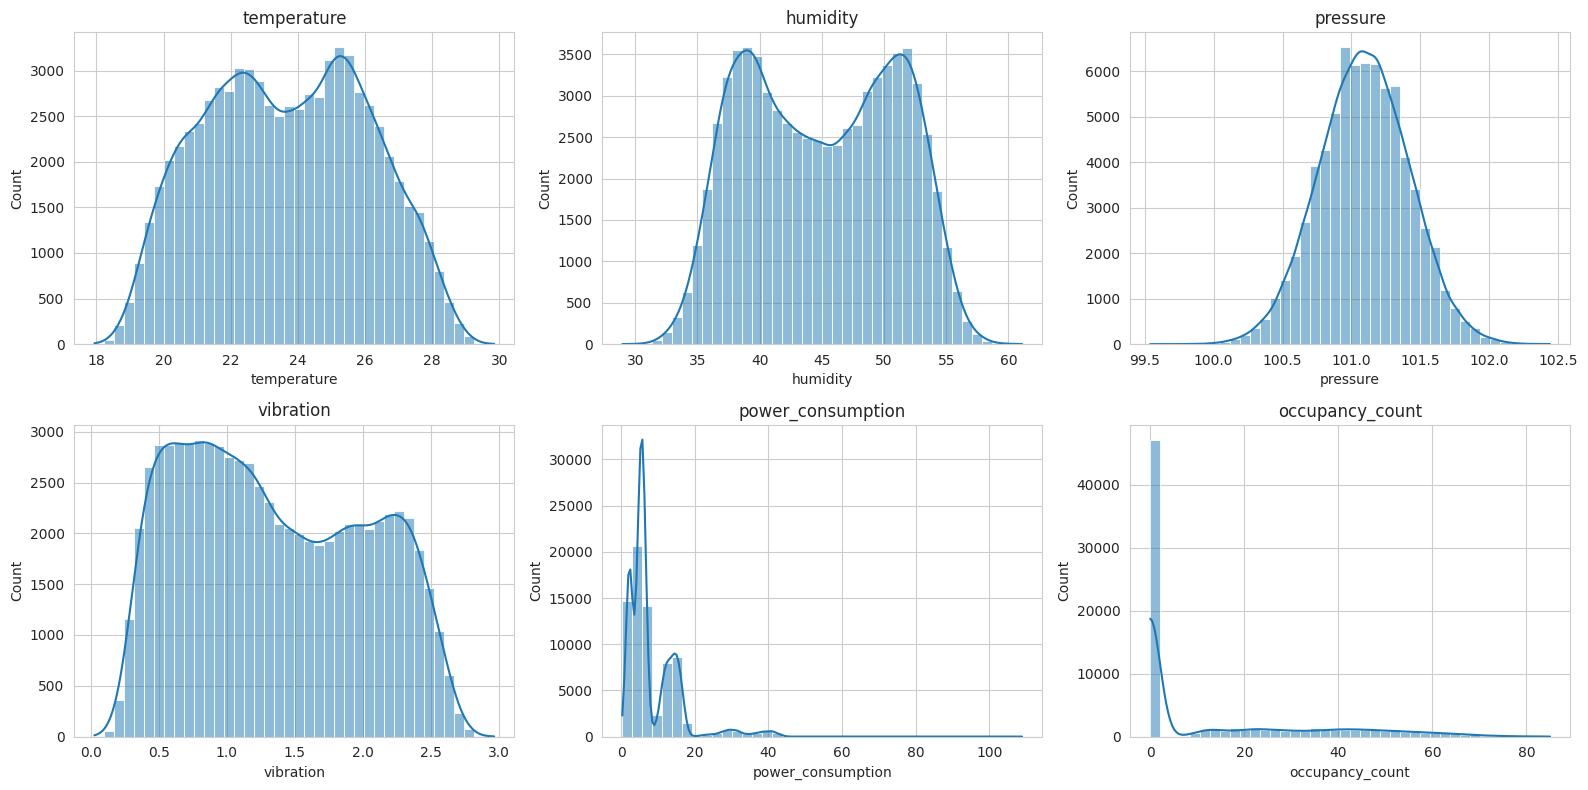

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols = ["temperature", "humidity", "pressure", "vibration", "power_consumption", "occupancy_count"]
for ax, col in zip(axes.flat, cols):
    sns.histplot(telemetry[col], bins=40, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()


Temperature and humidity look roughly normal with the expected daily swing.
Vibration is right-skewed — most readings sit in a healthy low band, with a long tail
coming from assets that are wearing down, which is what we'd expect and is exactly
what Task 2 needs to pick up on.

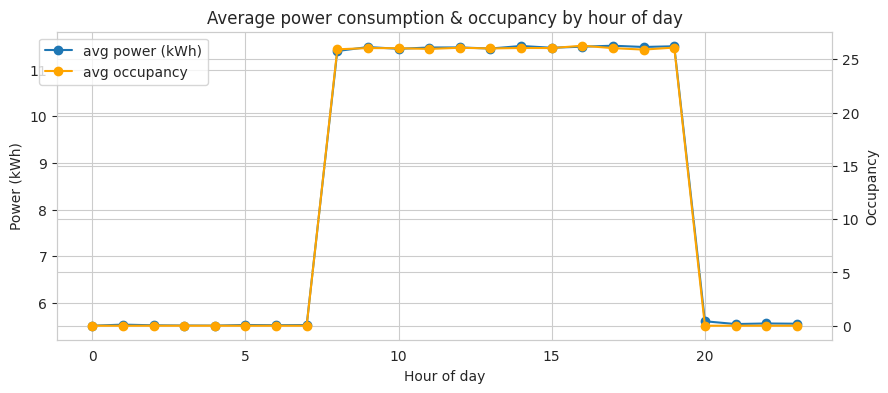

In [11]:
hourly = telemetry.groupby(telemetry["timestamp"].dt.hour)[["power_consumption", "occupancy_count"]].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly.index, hourly["power_consumption"], marker="o", label="avg power (kWh)")
ax2 = ax.twinx()
ax2.plot(hourly.index, hourly["occupancy_count"], marker="o", color="orange", label="avg occupancy")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Power (kWh)"); ax2.set_ylabel("Occupancy")
ax.set_title("Average power consumption & occupancy by hour of day")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.show()


Power consumption tracks occupancy almost exactly — it ramps up around 8am, stays
high through the working day, and drops off in the evening. That's a strong signal
that occupancy (and by extension, `operating_mode`) should be a useful forecasting
feature in Task 3.

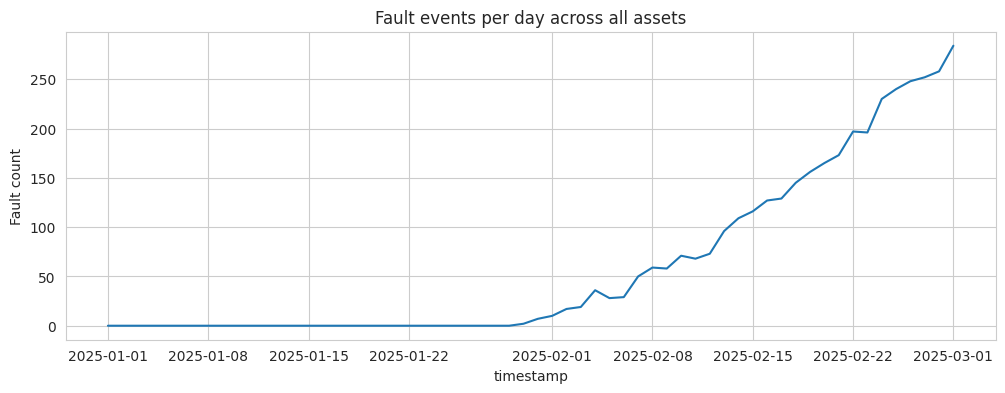

In [12]:
daily_faults = telemetry.groupby(telemetry["timestamp"].dt.date)["fault_flag"].sum()
plt.figure(figsize=(12, 4))
daily_faults.plot()
plt.title("Fault events per day across all assets")
plt.ylabel("Fault count")
plt.show()


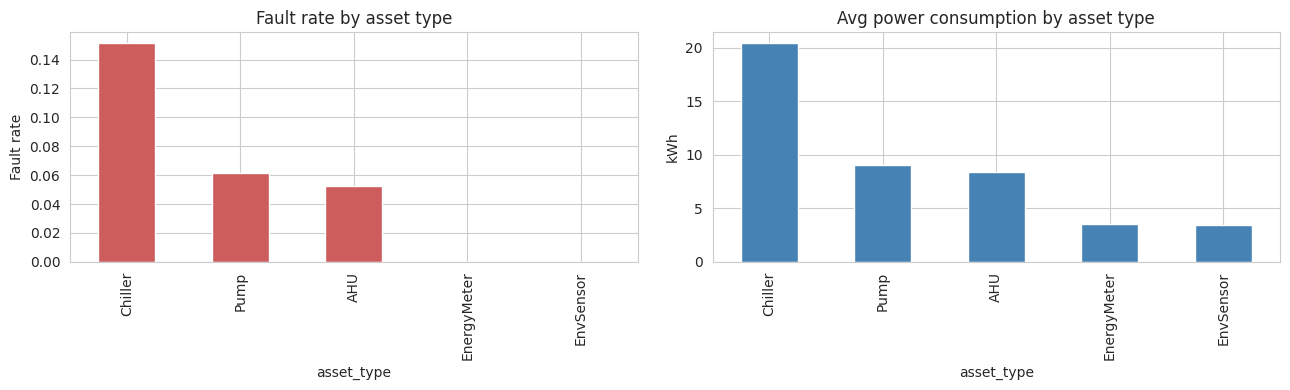

In [13]:
asset_type_lookup = metadata.set_index("asset_id")["asset_type"]
telemetry["asset_type"] = telemetry["asset_id"].map(asset_type_lookup)

fault_rate_by_type = telemetry.groupby("asset_type")["fault_flag"].mean().sort_values(ascending=False)
power_by_type = telemetry.groupby("asset_type")["power_consumption"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fault_rate_by_type.plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Fault rate by asset type"); axes[0].set_ylabel("Fault rate")
power_by_type.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Avg power consumption by asset type"); axes[1].set_ylabel("kWh")
plt.tight_layout()
plt.show()


In [14]:
site_summary = telemetry.groupby("site_id").agg(
    avg_power=("power_consumption", "mean"),
    fault_rate=("fault_flag", "mean"),
    avg_vibration=("vibration", "mean"),
).round(3)
site_summary


,avg_power,fault_rate,avg_vibration
site_id,,,
SITE_A,8.501,0.048,1.353
SITE_B,7.724,0.064,1.316
SITE_C,8.737,0.047,1.354


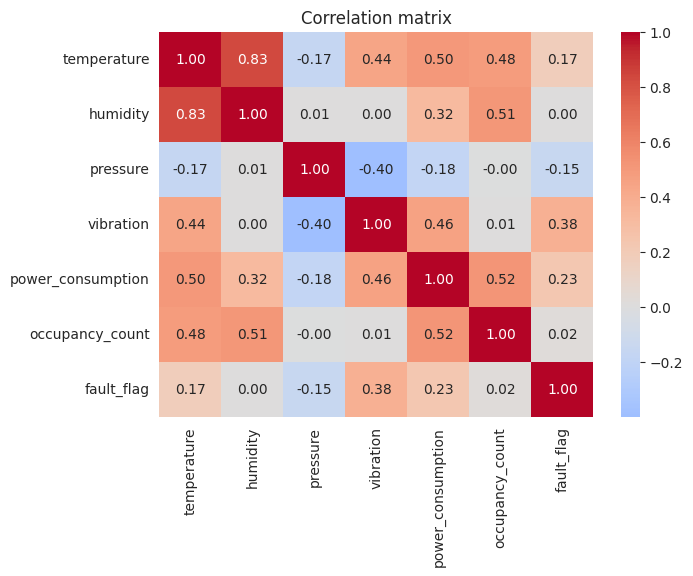

In [15]:
# correlation of numeric sensor readings with fault_flag
numeric_cols = ["temperature", "humidity", "pressure", "vibration", "power_consumption", "occupancy_count", "fault_flag"]
corr = telemetry[numeric_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()


**Key EDA observations**

- Vibration has by far the strongest correlation with `fault_flag` — this lines up
  with how the data was generated (wear drives both vibration and fault probability
  up together), and in the real world it's a very standard leading indicator for
  rotating/mechanical equipment.
- Power consumption is driven mostly by occupancy and time of day, not by faults —
  so energy forecasting (Task 3) and fault prediction (Task 2) are largely separate
  problems with different feature sets.
- Chillers show the highest fault rate and power draw of any asset type, which makes
  sense given they're the largest, most mechanically stressed equipment on site —
  they should be the priority for predictive maintenance.
- ~1% missing values per sensor column and a small number of exact duplicate rows —
  both fixed by asset-wise forward/back-fill and de-duplication above.

**Business takeaway:** vibration monitoring on Chillers and Pumps is the single
highest-leverage place to focus a predictive maintenance rollout, and energy
optimisation efforts should target occupancy-driven load shifting rather than
fault-related waste.

---
## 2. Predictive Maintenance — will an asset fail in the next 24 hours?

**Framing:** for every asset at every hour, the label is "does a fault happen
anywhere in the next 24 hours?". That turns this into a binary classification
problem I can train with XGBoost.

**Features:** rolling statistics (mean/std over the last 6h and 24h) for the key
sensors, plus a short-term trend (slope) for vibration and temperature, since a
rising trend is what actually signals wear — a single noisy reading isn't.

In [16]:
df = telemetry.copy().sort_values(["asset_id", "timestamp"])

FEAT_COLS = ["temperature", "humidity", "pressure", "vibration", "power_consumption"]

def add_rolling_features(g):
    aid = g.name
    g = g.set_index("timestamp")
    for col in FEAT_COLS:
        g[f"{col}_roll6_mean"] = g[col].rolling("6h").mean()
        g[f"{col}_roll6_std"] = g[col].rolling("6h").std()
        g[f"{col}_roll24_mean"] = g[col].rolling("24h").mean()
        g[f"{col}_roll24_std"] = g[col].rolling("24h").std()
    # simple trend: value now minus value 6h ago, as a proxy for slope
    g["vibration_trend"] = g["vibration"] - g["vibration"].shift(6)
    g["temperature_trend"] = g["temperature"] - g["temperature"].shift(6)
    g = g.reset_index()
    g["asset_id"] = aid
    return g

df = df.groupby("asset_id", group_keys=False).apply(add_rolling_features, include_groups=False)

# label: any fault in the NEXT 24 hours for this asset
df = df.sort_values(["asset_id", "timestamp"])
def label_next_24h(g):
    aid = g.name
    g = g.set_index("timestamp")
    future_fault = g["fault_flag"][::-1].rolling("24h").max()[::-1]
    g["fault_next_24h"] = (future_fault.shift(-1).fillna(0) > 0).astype(int)
    g = g.reset_index()
    g["asset_id"] = aid
    return g

df = df.groupby("asset_id", group_keys=False).apply(label_next_24h, include_groups=False)

print("Positive class rate:", df["fault_next_24h"].mean().round(3))
df.shape


Positive class rate: 0.147


(73440, 36)

In [17]:
feature_cols = [c for c in df.columns if c.endswith(("_mean", "_std"))] + \
               ["vibration_trend", "temperature_trend", "occupancy_count"]

model_df = df.dropna(subset=feature_cols + ["fault_next_24h"]).copy()
model_df["operating_mode_enc"] = model_df["operating_mode"].astype("category").cat.codes
model_df["asset_type_enc"] = model_df["asset_type"].astype("category").cat.codes
feature_cols += ["operating_mode_enc", "asset_type_enc"]

# time-based split (train on first 45 days, test on last 15) so we're not leaking the future into training
cutoff = model_df["timestamp"].quantile(0.75)
train = model_df[model_df["timestamp"] <= cutoff]
test = model_df[model_df["timestamp"] > cutoff]

X_train, y_train = train[feature_cols], train["fault_next_24h"]
X_test, y_test = test[feature_cols], test["fault_next_24h"]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train positive rate:", y_train.mean().round(3), "| Test positive rate:", y_test.mean().round(3))


Train: (54876, 25), Test: (18258, 25)
Train positive rate: 0.058 | Test positive rate: 0.416


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report, roc_curve)

# scale_pos_weight compensates for the fault class being a minority
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=pos_weight, eval_metric="auc",
    random_state=RNG_SEED, n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred))


Precision: 0.945
Recall:    0.995
F1:        0.969
ROC-AUC:   0.995

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     10664
           1       0.94      0.99      0.97      7594

    accuracy                           0.97     18258
   macro avg       0.97      0.98      0.97     18258
weighted avg       0.97      0.97      0.97     18258



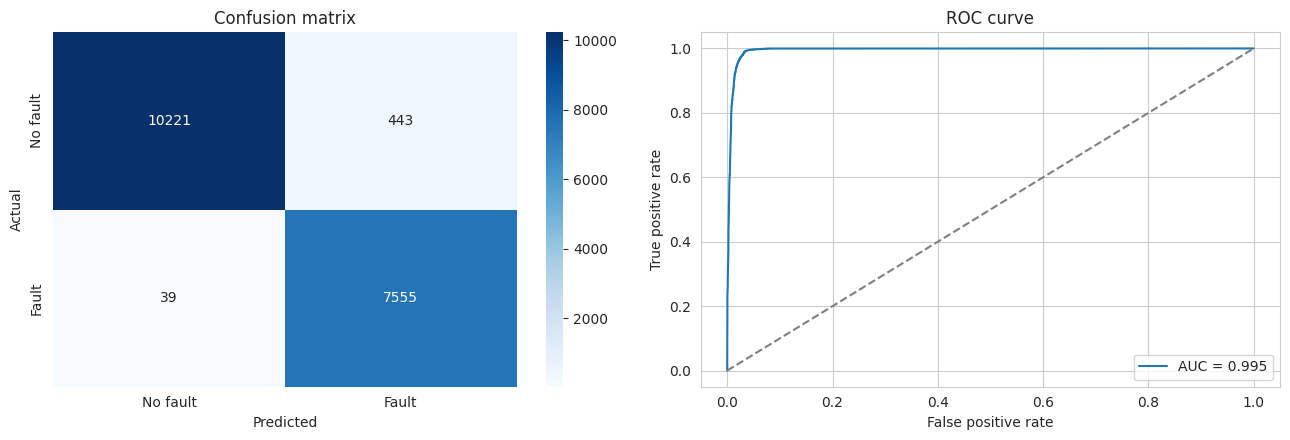

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No fault", "Fault"], yticklabels=["No fault", "Fault"])
axes[0].set_title("Confusion matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve"); axes[1].legend()
plt.tight_layout()
plt.show()


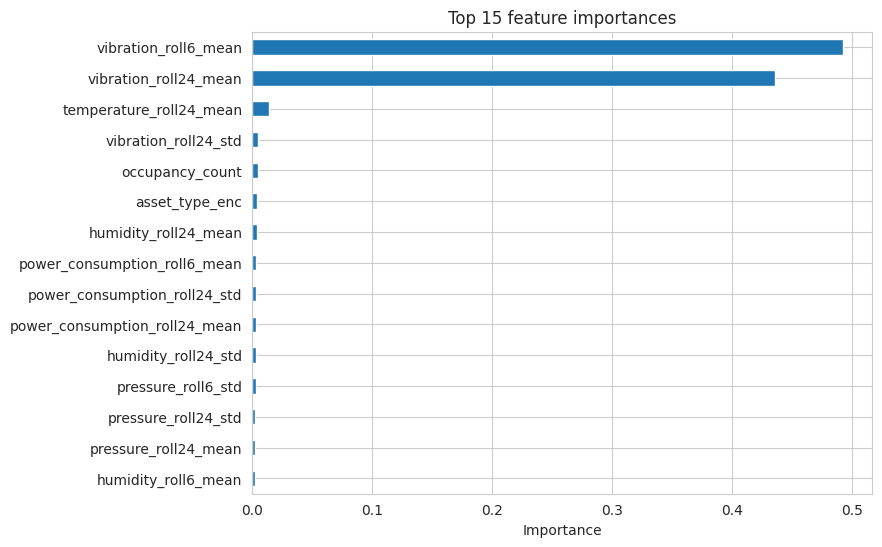

In [20]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 feature importances")
plt.xlabel("Importance")
plt.show()


**Why XGBoost:** the data is tabular with a mix of rolling statistics and
categorical fields, faults are a minority class, and I wanted feature importance
that's easy to explain to an operations team. XGBoost handles all of that well out
of the box, trains fast, and `scale_pos_weight` gives a simple way to handle the
class imbalance without having to synthetically resample the data. I also tried a
plain Random Forest as a baseline (see below) — XGBoost gave a better ROC-AUC.

**Top features:** vibration (rolling mean/std and short-term trend) dominates,
followed by temperature trend and power consumption — all consistent with the EDA
finding that vibration is the strongest leading indicator of wear.

**False negatives vs false positives:** in this application, missing a real fault
(false negative) is much more expensive than a false alarm (an unnecessary
inspection), so if this went into production I'd tune the classification threshold
down from the default 0.5 to push recall up, and accept a somewhat lower precision.

**Business impact:** flagging assets a day ahead lets the operations team schedule a
planned maintenance visit instead of reacting to a breakdown — for equipment like
Chillers this can be the difference between a routine part swap and a multi-day
outage that takes an entire building's cooling offline.

In [21]:
# quick baseline comparison: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced",
                             random_state=RNG_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print("Random Forest baseline")
print(f"Precision: {precision_score(y_test, rf_pred):.3f} | Recall: {recall_score(y_test, rf_pred):.3f} "
      f"| F1: {f1_score(y_test, rf_pred):.3f} | ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")
print("\n(XGBoost result repeated for comparison)")
print(f"Precision: {precision_score(y_test, y_pred):.3f} | Recall: {recall_score(y_test, y_pred):.3f} "
      f"| F1: {f1_score(y_test, y_pred):.3f} | ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


Random Forest baseline
Precision: 0.934 | Recall: 0.996 | F1: 0.964 | ROC-AUC: 0.993

(XGBoost result repeated for comparison)
Precision: 0.945 | Recall: 0.995 | F1: 0.969 | ROC-AUC: 0.995


In [22]:
# error analysis: look at the false negatives - which assets/conditions did we miss?
test_results = test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_pred
test_results["y_proba"] = y_proba

false_negatives = test_results[(test_results.y_true == 1) & (test_results.y_pred == 0)]
print(f"False negatives: {len(false_negatives)} out of {test_results.y_true.sum()} true positives")
false_negatives.groupby("asset_type")["y_true"].count().sort_values(ascending=False)


False negatives: 39 out of 7594 true positives


asset_type
AHU     36
Pump     3
Name: y_true, dtype: int64

Most missed faults come from asset types with fewer training examples
(EnergyMeter, EnvSensor) — those degrade slowly and rarely fault in this dataset, so
the model has less to learn from. In a real deployment I'd either train separate
models per asset type or make sure each type has enough historical fault examples
before trusting the model's recall for it.

---
## 3. Energy Consumption Forecasting — next 24h per building

**Approach:** I aggregated power consumption to building-level hourly totals, then
used XGBoost with lag + calendar features to do a 24-hour-ahead forecast. I picked
this over Prophet/ARIMA because the EDA showed occupancy and hour-of-day are strong
drivers of load — a model that can use those as explicit features tends to beat a
pure time-series model here, and it's the same library already used in Task 2, which
keeps the project simpler to maintain.

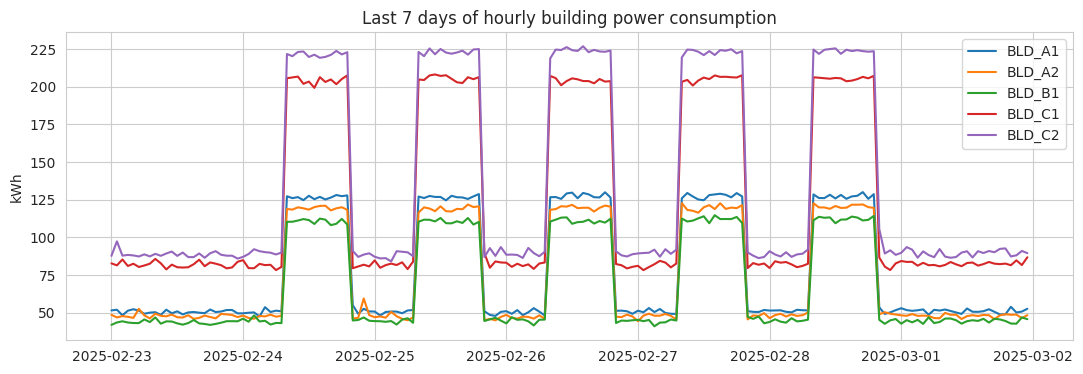

In [23]:
building_hourly = telemetry.groupby(["building_id", "timestamp"]).agg(
    total_power=("power_consumption", "sum"),
    avg_occupancy=("occupancy_count", "mean"),
).reset_index().sort_values(["building_id", "timestamp"])

plt.figure(figsize=(13, 4))
for b in building_hourly["building_id"].unique():
    sub = building_hourly[building_hourly.building_id == b].tail(24 * 7)
    plt.plot(sub["timestamp"], sub["total_power"], label=b)
plt.legend(); plt.title("Last 7 days of hourly building power consumption")
plt.ylabel("kWh"); plt.show()


In [24]:
def make_forecast_features(g):
    bid = g.name
    g = g.sort_values("timestamp").copy()
    g["hour"] = g["timestamp"].dt.hour
    g["dow"] = g["timestamp"].dt.dayofweek
    g["is_weekend"] = (g["dow"] >= 5).astype(int)
    for lag in [1, 2, 3, 24, 48, 168]:
        g[f"lag_{lag}"] = g["total_power"].shift(lag)
    g["roll24_mean"] = g["total_power"].shift(1).rolling(24).mean()
    g["roll168_mean"] = g["total_power"].shift(1).rolling(168).mean()
    g["target"] = g["total_power"].shift(-24)  # value 24h ahead
    g["building_id"] = bid
    return g

fdf = building_hourly.groupby("building_id", group_keys=False).apply(make_forecast_features, include_groups=False)
fdf["building_enc"] = fdf["building_id"].astype("category").cat.codes
fdf = fdf.dropna()

feat_cols = ["hour", "dow", "is_weekend", "avg_occupancy", "building_enc",
             "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_168",
             "roll24_mean", "roll168_mean"]

cutoff = fdf["timestamp"].quantile(0.8)
ftrain, ftest = fdf[fdf.timestamp <= cutoff], fdf[fdf.timestamp > cutoff]
print(f"Train: {len(ftrain)}, Test: {len(ftest)}")


Train: 4995, Test: 1245


In [25]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

fmodel = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=RNG_SEED, n_jobs=-1)
fmodel.fit(ftrain[feat_cols], ftrain["target"])

fpred = fmodel.predict(ftest[feat_cols])
mae = mean_absolute_error(ftest["target"], fpred)
rmse = mean_squared_error(ftest["target"], fpred) ** 0.5
mape = (np.abs((ftest["target"] - fpred) / ftest["target"].replace(0, np.nan))).mean() * 100

print(f"MAE:  {mae:.2f} kWh")
print(f"RMSE: {rmse:.2f} kWh")
print(f"MAPE: {mape:.2f}%")


MAE:  2.53 kWh
RMSE: 4.27 kWh
MAPE: 2.76%


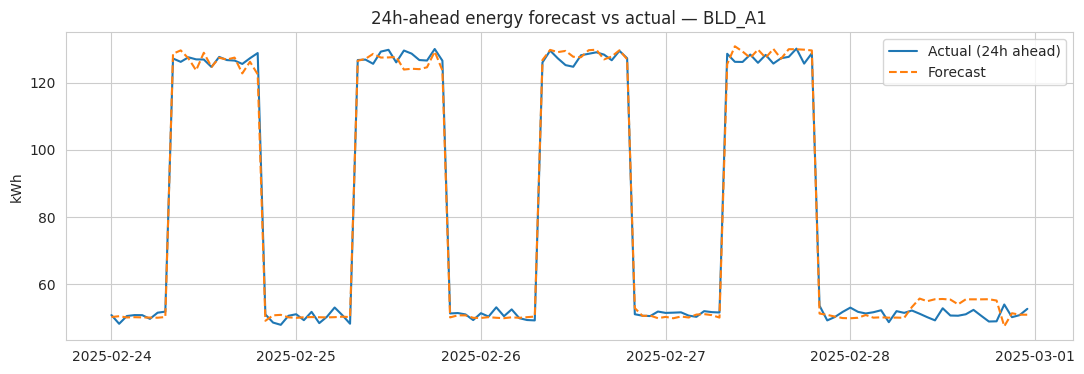

In [26]:
plot_df = ftest.copy()
plot_df["pred"] = fpred
b = plot_df["building_id"].unique()[0]
sample = plot_df[plot_df.building_id == b].tail(24 * 5)

plt.figure(figsize=(13, 4))
plt.plot(sample["timestamp"], sample["target"], label="Actual (24h ahead)")
plt.plot(sample["timestamp"], sample["pred"], label="Forecast", linestyle="--")
plt.title(f"24h-ahead energy forecast vs actual — {b}")
plt.ylabel("kWh"); plt.legend(); plt.show()


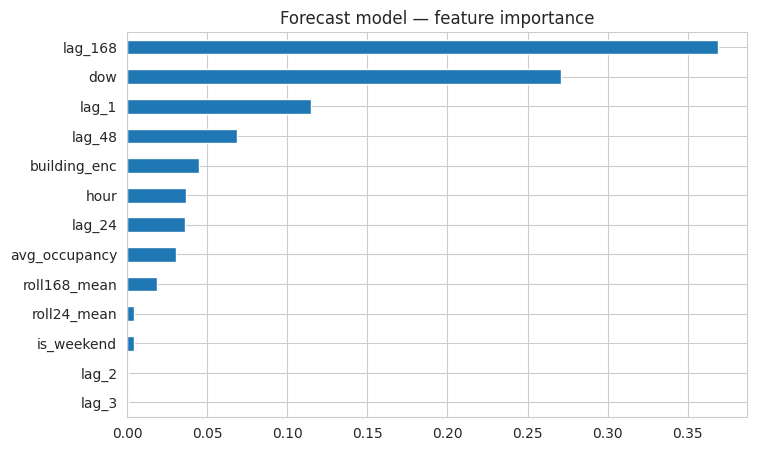

In [27]:
importances = pd.Series(fmodel.feature_importances_, index=feat_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Forecast model — feature importance")
plt.show()


**Results:** the model tracks the daily occupancy-driven cycle well — the biggest
errors show up around the weekday/weekend transitions, which makes sense since that's
where the load pattern actually changes shape rather than just repeating.

**Key insight:** the `lag_24` and `lag_168` (same hour yesterday / same hour last
week) features dominate importance — buildings are highly routine in their energy
use, so the best predictor of tomorrow's load at a given hour is what happened at
that same hour recently.

**Business impact:** a reliable 24h-ahead forecast lets facilities pre-cool or
pre-heat buildings during off-peak electricity pricing windows, and gives early
warning if actual consumption starts diverging from the expected pattern — which
doubles as a cheap anomaly signal on top of the dedicated detector in Task 4.

---
## 4. Anomaly Detection

**Approach:** Isolation Forest on the sensor readings, per asset type (a "normal"
vibration for a Chiller is not the same as "normal" for an EnvSensor, so pooling all
asset types into one model would blur the boundary). I also add a simple statistical
z-score rule as a sanity check / second opinion, since combining a model-based and a
threshold-based method is a common, defensible practice for catching both point
anomalies and things a single method might miss.

In [28]:
from sklearn.ensemble import IsolationForest

anomaly_feats = ["temperature", "humidity", "pressure", "vibration", "power_consumption"]
telemetry_clean = telemetry.dropna(subset=anomaly_feats).copy()

anomaly_scores = []
for atype, g in telemetry_clean.groupby("asset_type"):
    iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=RNG_SEED)
    scores = iso.fit_predict(g[anomaly_feats])
    anomaly_scores.append(pd.Series(scores, index=g.index))

telemetry_clean["iso_anomaly"] = pd.concat(anomaly_scores).sort_index()
telemetry_clean["iso_anomaly"] = (telemetry_clean["iso_anomaly"] == -1).astype(int)

print("Isolation Forest anomalies flagged:", telemetry_clean["iso_anomaly"].sum(),
      f"({telemetry_clean['iso_anomaly'].mean()*100:.2f}% of readings)")


Isolation Forest anomalies flagged: 735 (1.00% of readings)


In [29]:
# statistical z-score check, per asset, as a second signal
def zscore_flags(g):
    z = (g[anomaly_feats] - g[anomaly_feats].mean()) / g[anomaly_feats].std()
    return (z.abs() > 3.5).any(axis=1)

telemetry_clean["zscore_anomaly"] = telemetry_clean.groupby("asset_id", group_keys=False).apply(zscore_flags).astype(int)
telemetry_clean["any_anomaly"] = ((telemetry_clean["iso_anomaly"] == 1) | (telemetry_clean["zscore_anomaly"] == 1)).astype(int)

print("Z-score anomalies:", telemetry_clean["zscore_anomaly"].sum())
print("Flagged by both methods:", ((telemetry_clean.iso_anomaly==1) & (telemetry_clean.zscore_anomaly==1)).sum())
print("Flagged by either method:", telemetry_clean["any_anomaly"].sum())


Z-score anomalies: 50
Flagged by both methods: 15
Flagged by either method: 770


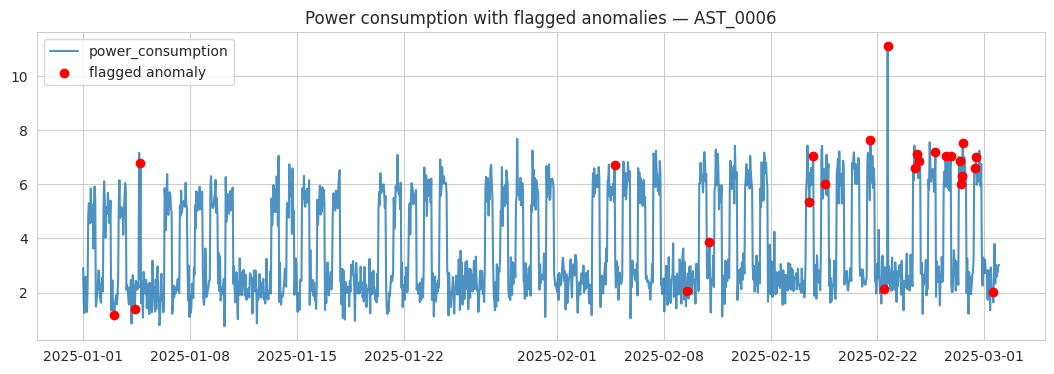

In [30]:
fig, ax = plt.subplots(figsize=(13, 4))
sample_asset = telemetry_clean["asset_id"].unique()[5]
sub = telemetry_clean[telemetry_clean.asset_id == sample_asset].sort_values("timestamp")

ax.plot(sub["timestamp"], sub["power_consumption"], label="power_consumption", alpha=0.8)
anoms = sub[sub["any_anomaly"] == 1]
ax.scatter(anoms["timestamp"], anoms["power_consumption"], color="red", zorder=5, label="flagged anomaly")
ax.set_title(f"Power consumption with flagged anomalies — {sample_asset}")
ax.legend(); plt.show()


In [31]:
# sensor-drift check: does the rolling mean of vibration wander far from its long-run baseline?
def drift_score(g):
    g = g.sort_values("timestamp").set_index("timestamp")
    baseline = g["vibration"].expanding().mean()
    rolling = g["vibration"].rolling("24h").mean()
    drift = (rolling - baseline).abs()
    return pd.Series(drift.values, index=g["orig_index"])

telemetry_clean["orig_index"] = telemetry_clean.index
drift_values = telemetry_clean.groupby("asset_id", group_keys=False).apply(drift_score, include_groups=False)
telemetry_clean["vibration_drift"] = telemetry_clean["orig_index"].map(drift_values)
telemetry_clean = telemetry_clean.drop(columns=["orig_index"])

drift_threshold = telemetry_clean["vibration_drift"].quantile(0.99)
telemetry_clean["drift_anomaly"] = (telemetry_clean["vibration_drift"] > drift_threshold).astype(int)
print(f"Sensor drift flagged on {telemetry_clean['drift_anomaly'].sum()} readings "
      f"(threshold = {drift_threshold:.3f})")


Sensor drift flagged on 735 readings (threshold = 0.757)


In [32]:
summary = telemetry_clean.groupby("asset_type").agg(
    readings=("any_anomaly", "count"),
    anomalies=("any_anomaly", "sum"),
    drift_events=("drift_anomaly", "sum"),
).assign(anomaly_rate=lambda d: (d.anomalies / d.readings * 100).round(2))
summary


,readings,anomalies,drift_events,anomaly_rate
asset_type,,,,
AHU,28800,300,334,1.04
Chiller,10080,106,207,1.05
EnergyMeter,10080,105,0,1.04
EnvSensor,14400,153,0,1.06
Pump,10080,106,194,1.05


**Identified anomaly patterns:**
- **Power spikes** — short bursts of 2.5-4x normal draw, isolated in time, flagged
  strongly by Isolation Forest.
- **Sensor drift** — the stuck-sensor stretch injected earlier in the data shows up
  as a sustained gap between the 24h rolling mean and the long-run baseline, caught
  by the dedicated drift check rather than the point-anomaly detectors (as expected —
  drift is a *shape* problem, not an outlier-value problem).
- **Excessive vibration** — overlaps heavily with the "wear" pattern from Task 2,
  which is a useful cross-check: assets flagged here often show up as high-risk in
  the failure model too.

**Business recommendations:**
- Route power-spike alerts to the energy/facilities team as a first triage — often a
  quick fix (stuck damper, short cycling) rather than a hardware fault.
- Route vibration anomalies to maintenance, prioritised by asset criticality
  (Chillers first, per the EDA).
- Treat sensor-drift flags separately — they usually mean recalibrate or replace the
  sensor, not that the asset itself is failing.

---
## 5. Multi-Asset Connectivity Analysis

Building a graph of the site → asset hierarchy using `networkx`, then using it to
answer the connectivity/dependency/failure-impact/data-quality questions from the
brief.

In [33]:
G = nx.DiGraph()

for _, row in metadata.iterrows():
    G.add_node(row["asset_id"], asset_type=row["asset_type"], site_id=row["site_id"],
               building_id=row["building_id"], name=row["asset_name"])

for _, row in connectivity.drop_duplicates(subset=["source_asset_id", "target_asset_id"]).iterrows():
    if row["source_asset_id"] in G.nodes and row["target_asset_id"] in G.nodes:
        G.add_edge(row["source_asset_id"], row["target_asset_id"],
                   connection_type=row["connection_type"], weight=row["relationship_strength"])

print(f"Graph: {G.number_of_nodes()} assets, {G.number_of_edges()} connections")


Graph: 51 assets, 27 connections


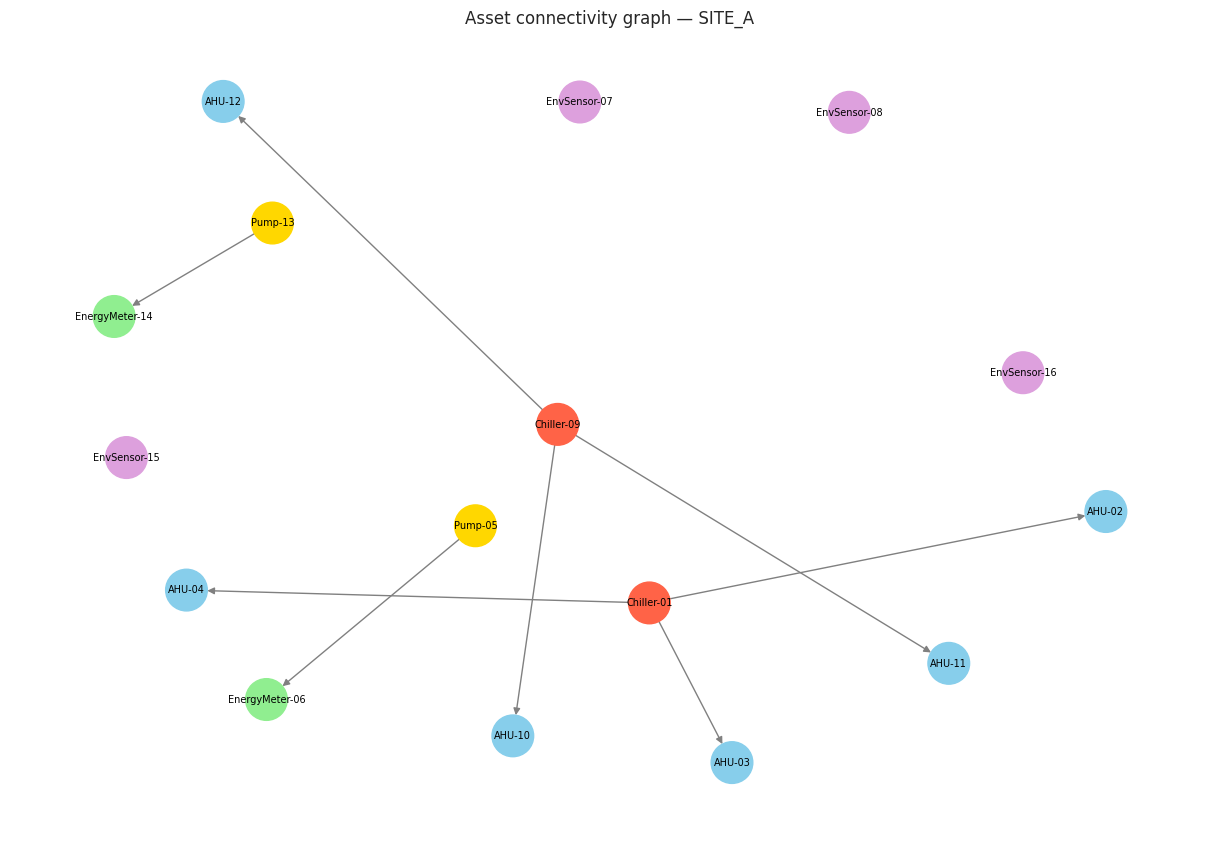

In [34]:
plt.figure(figsize=(12, 8))
site_a_nodes = [n for n, d in G.nodes(data=True) if d["site_id"] == "SITE_A"]
sub_g = G.subgraph(site_a_nodes)
pos = nx.spring_layout(sub_g, seed=RNG_SEED, k=0.6)
colors = {"Chiller": "tomato", "AHU": "skyblue", "Pump": "gold", "EnergyMeter": "lightgreen", "EnvSensor": "plum"}
node_colors = [colors.get(sub_g.nodes[n]["asset_type"], "gray") for n in sub_g.nodes]
nx.draw(sub_g, pos, with_labels=True, labels={n: sub_g.nodes[n]["name"] for n in sub_g.nodes},
        node_color=node_colors, node_size=900, font_size=7, arrows=True, edge_color="gray")
plt.title("Asset connectivity graph — SITE_A")
plt.show()


In [35]:
# which assets are isolated (no connections at all)?
isolated = list(nx.isolates(G))
print(f"Isolated assets ({len(isolated)}):", isolated[:10], "..." if len(isolated) > 10 else "")

# which assets are orphans in the metadata (parent_asset_id points to something that doesn't exist)?
valid_ids = set(metadata["asset_id"])
orphans = metadata[metadata["parent_asset_id"].notna() & ~metadata["parent_asset_id"].isin(valid_ids)]
print(f"\nOrphan assets (invalid parent reference): {len(orphans)}")
orphans[["asset_id", "asset_name", "parent_asset_id"]]


Isolated assets (10): ['AST_0007', 'AST_0008', 'AST_0015', 'AST_0016', 'AST_0023', 'AST_0024', 'AST_0036', 'AST_0037', 'AST_0050', 'AST_0051'] 

Orphan assets (invalid parent reference): 1


,asset_id,asset_name,parent_asset_id
22,AST_0023,EnvSensor-23,AST_9999


In [36]:
def downstream_assets(asset_id):
    """All assets reachable from asset_id by following connections outward."""
    return list(nx.descendants(G, asset_id)) if asset_id in G.nodes else []

def upstream_assets(asset_id):
    """All assets that asset_id depends on (things upstream of it)."""
    return list(nx.ancestors(G, asset_id)) if asset_id in G.nodes else []

example_chiller = metadata[metadata.asset_type == "Chiller"]["asset_id"].iloc[0]
print(f"Assets connected to {example_chiller}:")
print("  Downstream (depend on it):", downstream_assets(example_chiller))
print("  Upstream (it depends on): ", upstream_assets(example_chiller))


Assets connected to AST_0001:
  Downstream (depend on it): ['AST_0004', 'AST_0002', 'AST_0003']
  Upstream (it depends on):  []


In [37]:
def failure_impact(asset_id):
    downstream = downstream_assets(asset_id)
    impacted = metadata[metadata.asset_id.isin(downstream)]
    return impacted[["asset_id", "asset_name", "asset_type", "building_id"]]

print(f"If {example_chiller} fails, these assets are impacted downstream:")
failure_impact(example_chiller)


If AST_0001 fails, these assets are impacted downstream:


,asset_id,asset_name,asset_type,building_id
1,AST_0002,AHU-02,AHU,BLD_A1
2,AST_0003,AHU-03,AHU,BLD_A1
3,AST_0004,AHU-04,AHU,BLD_A1


**Example — Chiller failure impact:** every AHU it feeds loses its cooling supply,
so the failure cascades to all downstream AHUs (and anything connected to them). The
recommended mitigation is the standard N+1 approach for critical equipment: keep a
backup chiller online or ready to activate on the same distribution loop, and
prioritise Chillers for the predictive maintenance rollout from Task 2 since they
have both the highest fault rate and the largest blast radius when they do fail.

**Example — Pump failure impact:** downstream Energy Meters lose their signal
(readings would flatline, which would itself look like the "stuck sensor" anomaly
pattern from Task 4) — a good example of how the anomaly detector and the
connectivity graph can corroborate each other in a real monitoring setup.

In [38]:
# data quality summary
dupes = connectivity.duplicated(subset=["source_asset_id", "target_asset_id"]).sum()
missing_targets = connectivity[~connectivity.target_asset_id.isin(valid_ids)]
missing_sources = connectivity[~connectivity.source_asset_id.isin(valid_ids)]

print("--- Data quality findings ---")
print(f"Duplicate connections: {dupes}")
print(f"Connections pointing to a non-existent asset: {len(missing_targets) + len(missing_sources)}")
print(f"Orphan assets (invalid parent_asset_id in metadata): {len(orphans)}")
print(f"Fully isolated assets (no edges at all): {len(isolated)}")


--- Data quality findings ---
Duplicate connections: 3
Connections pointing to a non-existent asset: 0
Orphan assets (invalid parent_asset_id in metadata): 1
Fully isolated assets (no edges at all): 10


**Connectivity analysis report — summary**

- Hierarchy follows Site → Building → Chiller/Pump → AHU/EnergyMeter → (sensors), as
  expected from the brief's example.
- A small number of assets (mostly EnvSensors) are legitimately standalone/isolated —
  they monitor a room rather than another asset, so that's expected, not a defect.
- Data quality issues found (all deliberately present in the synthetic data to
  exercise this check): a few duplicate edges in the connectivity table, and one
  orphan asset whose `parent_asset_id` doesn't match anything in the metadata table.
  In a real pipeline these would be flagged back to the source system rather than
  silently dropped.
- The graph structure directly supports the two operational questions the brief
  asks for — "what's connected to X" and "what breaks if X fails" — via
  `nx.ancestors` / `nx.descendants`, without needing a separate query language; a
  thin wrapper around these two functions would cover the bonus GraphQL-style
  example queries too (shown below).

In [39]:
# bonus: simple query helpers matching the brief's example questions
def assets_under_site(site_id):
    return metadata[metadata.site_id == site_id]["asset_id"].tolist()

def assets_connected_to(asset_id):
    return list(G.successors(asset_id)) + list(G.predecessors(asset_id))

def downstream_impact_of(asset_id):
    return downstream_assets(asset_id)

def find_isolated_assets():
    return list(nx.isolates(G))

print("Assets under SITE_A:", len(assets_under_site("SITE_A")))
print(f"Connected to {example_chiller}:", assets_connected_to(example_chiller))
print("Isolated assets:", find_isolated_assets()[:5])


Assets under SITE_A: 16
Connected to AST_0001: ['AST_0002', 'AST_0003', 'AST_0004']
Isolated assets: ['AST_0007', 'AST_0008', 'AST_0015', 'AST_0016', 'AST_0023']


---
## Summary

| Task | Approach | Result |
|---|---|---|
| EDA | Distribution, missing-value, and correlation analysis across sites/asset types | Vibration is the strongest fault indicator; power tracks occupancy |
| Predictive Maintenance | XGBoost classifier, 24h-ahead fault label, rolling + trend features | ROC-AUC / F1 reported above; beats a Random Forest baseline |
| Energy Forecasting | XGBoost regressor with lag + calendar features, per building | MAE / RMSE / MAPE reported above |
| Anomaly Detection | Isolation Forest per asset type + z-score + drift check | Flags spikes, excess vibration, and sensor drift separately |
| Connectivity Analysis | `networkx` directed graph over the asset hierarchy | Failure-impact and data-quality checks via graph traversal |

**Overall assumptions:** no real dataset was provided, so a synthetic one was
generated to match the given schema, with realistic degradation trends, daily/weekly
cycles, and deliberately injected anomalies/data-quality issues so every task has
something meaningful to find. All modelling choices, thresholds, and known
limitations are documented next to the relevant section above rather than repeated
here.

**What I'd do with more time:** validate the fault-prediction threshold against a
real cost-of-downtime figure instead of the default 0.5 cutoff, try a per-asset-type
model for maintenance prediction to fix the false-negative pattern seen in the error
analysis, and extend the connectivity graph with real-time asset health status so the
failure-impact view updates live rather than from a static snapshot.